<a href="https://colab.research.google.com/github/DarkLord-13/Machine-Learning-01/blob/main/Llama3_RAG_for_web_url.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **See full article on [Meduim](https://medium.com/@tharindumadhusanka99/llama3-rag-on-google-colab-73c43aa53281)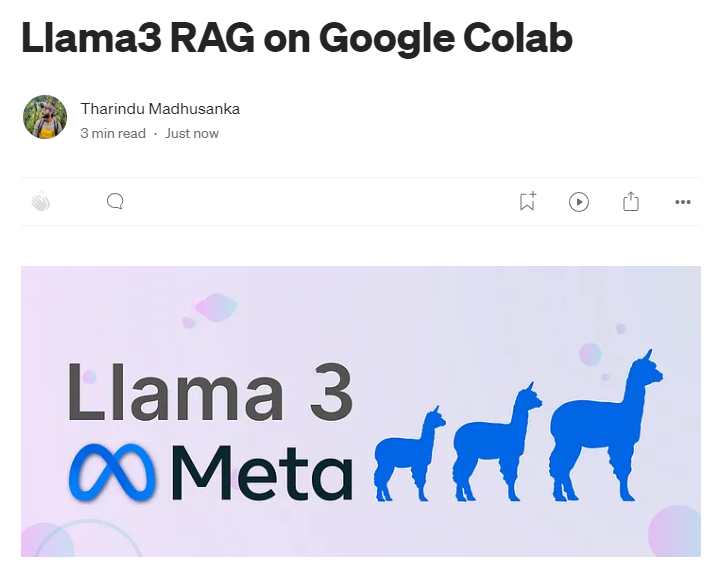**

In [ ]:
!pip install colab-xterm
%load_ext colabxterm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 2.7 MB/s eta 0:00:00


In [ ]:
# type these codes in below terminal after run the cell (%xterm)
# curl -fsSL https://ollama.com/install.sh | sh
# ollama serve & ollama pull llama3 & ollama pull nomic-embed-text

In [ ]:
%xterm

Launching Xterm...

<IPython.core.display.Javascript object>

In [ ]:
!pip -qq install langchain
!pip -qq install langchain-core
!pip -qq install langchain-community

In [ ]:
from langchain_community.llms import Ollama
llm = Ollama(model = "llama3")
llm.invoke("what is the Meaning of life")

"The meaning of life!\n\nThis question has puzzled philosophers, scientists, and thinkers for centuries. While there's no definitive answer, I'll provide an overview of various perspectives on what might give life its meaning.\n\n**Philosophical Perspectives**\n\n1. **Existentialism**: Jean-Paul Sartre's existentialist view posits that each individual must create their own meaning in life. We are free to choose our values and purpose.\n2. **Humanistic**: This perspective emphasizes the inherent value of human existence, focusing on personal growth, self-actualization, and happiness.\n3. **Teleological**: Aristotle believed that life has a natural order and purpose, with humans striving for virtue, happiness, and fulfillment.\n\n**Scientific Perspectives**\n\n1. **Evolutionary**: From an evolutionary perspective, the meaning of life might be to perpetuate the species, ensuring our genetic legacy through reproduction.\n2. **Biological**: Some scientists argue that the fundamental drive b

In [ ]:
!pip install ollama langchain beautifulsoup4 chromadb gradio -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 33.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 46.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.2/92.2 kB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 65.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.0/107.0 kB 13.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 8.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pypro

In [ ]:
import gradio as gr
import ollama
from bs4 import BeautifulSoup as bs
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import OllamaEmbeddings

# Load the data from the web URL
url = 'https://en.wikipedia.org/wiki/Ohiya'
loader = WebBaseLoader(url)
docs = loader.load()

# Split the loaded documents into chunks
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
splits = text_splitter.split_documents(docs)

# Create Ollama embeddings and vector store
embeddings = OllamaEmbeddings(model="nomic-embed-text")
vectorstore = Chroma.from_documents(documents=splits, embedding=embeddings)

# Define the function to call the Ollama Llama3 model
def ollama_llm(question, context):
    formatted_prompt = f"Question: {question}\n\nContext: {context}"
    response = ollama.chat(model='llama3', messages=[{'role': 'user', 'content': formatted_prompt}])
    return response['message']['content']

# Define the RAG setup
retriever = vectorstore.as_retriever()

def rag_chain(question):
    retrieved_docs = retriever.invoke(question)
    formatted_context = "\n\n".join(doc.page_content for doc in retrieved_docs)
    return ollama_llm(question, formatted_context)

# Define the Gradio interface
def get_important_facts(question):
    return rag_chain(question)

# Create a Gradio app interface
iface = gr.Interface(
  fn=get_important_facts,
  inputs=gr.Textbox(lines=2, placeholder="Enter your question here..."),
  outputs="text",
  title="RAG with Llama3",
  description="Ask questions about the proveded context",
)

# Launch the Gradio app
iface.launch()
